# 5. Hits and effects

This page asks which treatments moved away from the controls, and which measurements changed. Both answers come
with a p-value from a permutation null, and both are computed on the same object.

Two real screens are used, because the two questions need different designs: kinase inhibitors with many
replicate wells, and a plate of single cells for the questions a well median cannot answer. Potency has its own
page, [11. Concentration response](11_dose_response.ipynb).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

import mantispy as mt

## A screen with replicates

`pki` is the JUMP pilot's kinase inhibitor set: fifteen compounds over a dose range in U2OS, with 32 to 64
replicate wells per treatment {cite:p}`Chandrasekaran_2023`. That much replication is unusual, and it makes this
a good place to see what a hit call does when the design is generous.

The preparation is the sequence from [3. Trustworthy profiles](03_trustworthy_profiles.ipynb).

In [2]:
wells = mt.ds.pki()
mt.pp.normalize(wells, by="Metadata_Plate", reference="negcon")
# A feature with no spread among some plate's controls would be multiplied by up to 1e18.
wells = wells[:, ~wells.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(wells, na_cutoff=0.0)
wells = mt.pp.subset_features(wells)
sc.pp.pca(wells, n_comps=20)
wells

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/n7Ku6oea/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_37895/248375202.py:2: UserWarning: 133 of 5857 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(wells, by="Metadata_Plate", reference="negcon")


AnnData object with n_obs × n_vars = 3072 × 852
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X)

## Calling hits

{func}`~mantispy.tl.hit_calling` scores each group's median distance from the control centroid, measured in the
controls' own covariance so that directions the controls already vary in count for less. The null is the other
ways to draw a group of that size from the group and the held-out controls pooled.

With thousands of features and a few hundred control wells the covariance would be singular, so the distance is
read on a PCA representation. The function says so itself if you forget.

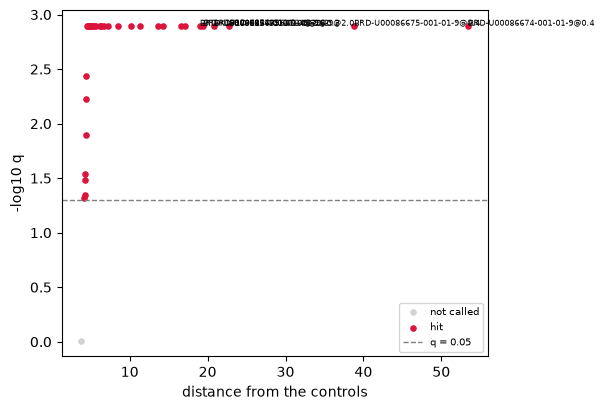

In [3]:
mt.tl.hit_calling(wells, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=1000)
ax = mt.pl.hits(wells, label_top=6)
plt.show()

In [4]:
hits = wells.uns["mantispy"]["hits"].set_index("group")
hits.sort_values("distance", ascending=False).head(6)

,n_obs,distance,pvalue,qvalue,is_hit
group,,,,,
BRD-U00086674-001-01-9@0.4,64,53.490374,0.000999,0.001265,True
BRD-U00086675-001-01-9@0.4,64,38.818986,0.000999,0.001265,True
BRD-K95785537-001-26-9@2.0,32,22.780632,0.000999,0.001265,True
BRD-U00086675-001-01-9@0.2,64,20.770808,0.000999,0.001265,True
BRD-U00086674-001-01-9@0.2,64,19.452408,0.000999,0.001265,True
BRD-K15179513-001-03-4@2.0,32,19.016517,0.000999,0.001265,True


## Which features moved

A hit call says a treatment moved. It does not say what changed. {func}`~mantispy.tl.effect_size` gives a
per-feature effect against the controls with Mann-Whitney p-values, and one BH correction over the whole table.

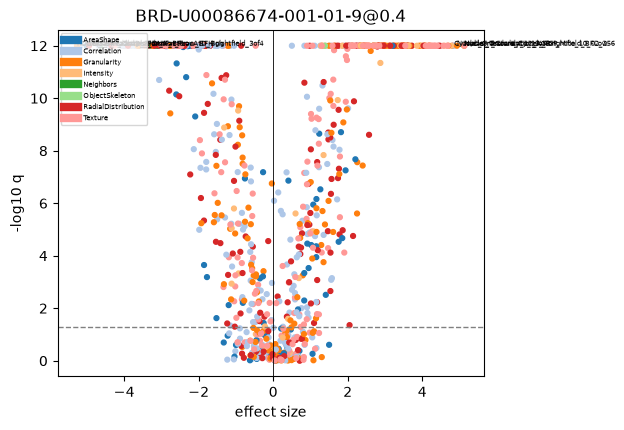

In [5]:
mt.tl.effect_size(wells, groupby="Metadata_Perturbation", reference="negcon")
strongest = hits.drop(index="DMSO")["distance"].idxmax()

ax = mt.pl.feature_volcano(wells, group=strongest)
ax.set_title(strongest)
plt.show()

Each point is one CellProfiler measurement. The named ones are where this compound's effect lives, and they are
the handle for the next question, whether two compounds move the same features, which is
[6. Mechanism of action](06_mechanism_of_action.ipynb).

## One profile per perturbation

Replicate wells of a treatment are combined into a signature with {func}`~mantispy.tl.consensus`.

In [6]:
signatures = mt.tl.consensus(wells, by="Metadata_Perturbation", method="median")
print(f"{wells.n_obs} wells -> {signatures.n_obs} signatures")
signatures

3072 wells -> 38 signatures


AnnData object with n_obs × n_vars = 38 × 852
    obs: 'Metadata_Perturbation', 'Metadata_ReplicateCount', 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Site_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy'
    layers: None (.X)

`median` is the default and is what pycytominer does by default. `modz` weights each replicate by how well it
agrees with the others, which helps when replicates are few and noisy and costs a little when they are plentiful,
as they are here.

## When the median hides the effect

A well median describes the average cell, and some treatments do not move the average one. A compound that
strongly changes a fifth of the cells and leaves the rest alone barely shifts the median while the distribution
grows a second mode.

That question needs single cells. `jump_cells` is 13,578 real cells from 24 wells of a JUMP plate.

In [7]:
cells = mt.ds.jump_cells()
mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")
cells = cells[:, ~cells.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(cells, na_cutoff=0.0)
cells = mt.pp.subset_features(cells)
sc.pp.pca(cells, n_comps=20)

for method in ("mahalanobis", "ks"):
    mt.tl.hit_calling(
        cells,
        groupby="Metadata_Perturbation",
        reference="negcon",
        use_rep="X_pca",
        method=method,
        n_permutations=500,
        key_added=method,
    )

comparison = pd.DataFrame(
    {
        "median distance": cells.uns["mantispy"]["mahalanobis"].set_index("group")["distance"],
        "KS statistic": cells.uns["mantispy"]["ks"].set_index("group")["distance"],
    }
)
comparison.sort_values("KS statistic", ascending=False).head(8)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_37895/2835558054.py:2: UserWarning: 285 of 5857 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")


,median distance,KS statistic
group,,
JCP2022_098688,6.519045,0.461533
JCP2022_115963,5.792811,0.442708
JCP2022_010404,5.308454,0.408338
JCP2022_067432,5.129466,0.406633
JCP2022_035095,4.842518,0.375029
JCP2022_116560,4.421658,0.280272
JCP2022_079715,4.209925,0.255126
JCP2022_001890,4.103572,0.247388


`method="mahalanobis"` asks whether the group's typical cell is far from the controls. `method="ks"` compares the
whole distribution of cell distances against the controls', so it answers a different question: whether *some*
cells moved, even when the middle of the distribution did not.

One caution applies to every cell-level test on this page. Cells from one well share its plate position, its
seeding density and its focus, so they are not independent draws; the unit the experiment randomized is the well.
A null that shuffles cells assumes more evidence than the design supports, and p-values come out small for
reasons that have nothing to do with the treatment. Read a cell-level call as a ranking, and put the well-level
call beside it before believing it.

## A change in shape

The same idea applies feature by feature. {func}`~mantispy.tl.effect_size` compares locations;
{func}`~mantispy.tl.wasserstein_features` compares whole distributions, so it sees a treatment that widens a
feature without moving its centre.

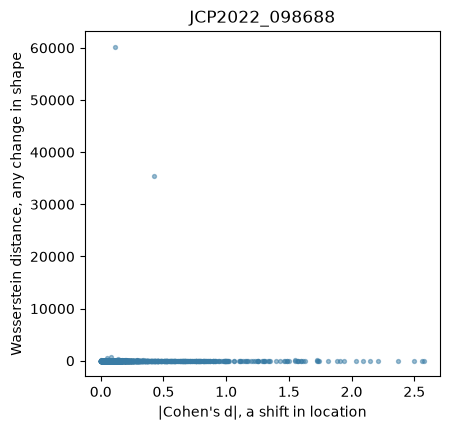

In [8]:
mt.tl.effect_size(cells, groupby="Metadata_Perturbation", reference="negcon")
mt.tl.wasserstein_features(cells, groupby="Metadata_Perturbation", reference="negcon")

treated = comparison["KS statistic"].drop(index="JCP2022_033924").idxmax()
effect = cells.uns["mantispy"]["effect"]
shift = cells.uns["mantispy"]["wasserstein"]
paired = pd.DataFrame(
    {
        "location": effect.loc[effect["group"] == treated].set_index("feature")["effect"].abs(),
        "shape": shift.loc[shift["group"] == treated].set_index("feature")["distance"],
    }
).dropna()

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(paired["location"], paired["shape"], s=8, alpha=0.5, color="#3a7ca5")
ax.set(xlabel="|Cohen's d|, a shift in location", ylabel="Wasserstein distance, any change in shape", title=treated)
fig.tight_layout()

Features along the diagonal moved their centre. Features high on the left changed shape without moving it much,
and a test on means alone cannot see them. [7. Single-cell heterogeneity](07_single_cell_heterogeneity.ipynb)
takes that further and asks which cells changed.

## What is on the object now

In [9]:
print("pki, well level")
print("  uns:", [k for k in ("hits", "effect") if k in wells.uns["mantispy"]])
print("  obs:", [c for c in wells.obs.columns if c.startswith("hits")])
print("\njump_cells, cell level")
print("  uns:", [k for k in ("mahalanobis", "ks", "effect", "wasserstein") if k in cells.uns["mantispy"]])
print("  obs:", [c for c in cells.obs.columns if c.startswith(("mahalanobis", "ks"))])

pki, well level
  uns: ['hits', 'effect']
  obs: ['hits_distance', 'hits_qvalue', 'hits_row_distance', 'hits_reference_held_out']

jump_cells, cell level
  uns: ['mahalanobis', 'ks', 'effect', 'wasserstein']
  obs: ['mahalanobis_distance', 'mahalanobis_qvalue', 'mahalanobis_row_distance', 'mahalanobis_reference_held_out', 'ks_distance', 'ks_qvalue', 'ks_row_distance', 'ks_reference_held_out']


Every result is a tidy table under `uns["mantispy"]`, and the per-row columns are joined back onto `obs`, so
{func}`~mantispy.io.write` keeps them and the plots read them without being handed anything.

Next: [6. Mechanism of action](06_mechanism_of_action.ipynb), which asks whether two treatments moved the same
way.